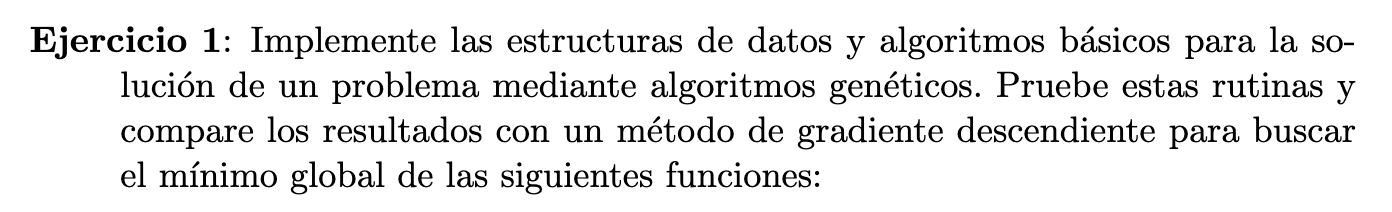

### Idea del algoritmo evolutivo

La idea es crear una población compuesta por individuos, donde cada individuo representa una posible solución a mi problema. Por ejemplo, en el ejercicio 1, el objetivo es encontrar el mínimo de una función, por lo que cada individuo representa un posible valor de `x`.

Para saber qué tan buena es una solución se utiliza una **función de aptitud**. En el ejercicio 1, usamos el opuesto de las funciones `f(x)` y `f(x,y)` como función de aptitud. Como nuestro objetivo es encontrar el mínimo, mientras **mayor** sea el valor obtenido, mejor es el individuo.

Se suele tener una **aptitud objetivo**, es decir, la mejor solución conocida o esperada para el problema, y la idea es encontrar un individuo que alcance esa aptitud o se acerque lo máximo posible. En este ejercicio, la mejor aptitud conocida es aproximadamente `418.98` para `f(x)` y `0` para `f(x,y)`.

Lo más probable es que en la población inicial, que se genera aleatoriamente dentro de un rango de valores, no encontremos directamente la solución óptima. Sin embargo, algunos individuos estarán más cerca de la solución que otros. Entonces, la idea es crear una nueva generación a partir de los individuos de la generación actual.

Hay diferentes formas de reemplazar una generación. Por ejemplo, está el **reemplazo generacional**, donde se reemplaza toda la población actual por los hijos, y el **reemplazo elitista**, donde se conservan algunos de los mejores individuos. En este caso utilicé reemplazo generacional, por lo que creo la misma cantidad de hijos que individuos tenía la población anterior.

Para crear un nuevo individuo se seleccionan dos individuos de la generación actual, que serán el padre y la madre. Para elegirlos utilicé un método de competencia: selecciono dos individuos al azar y comparo sus aptitudes. Como estamos minimizando, el que tenga la **menor aptitud** es el ganador. Hago esto dos veces, una para elegir al padre y otra para elegir a la madre.

Después de seleccionar los padres, transformo su representación de `x` a binario. Esto permite realizar fácilmente el cruce entre ambos individuos. En el ejercicio 1 utilizo 10 bits para representar los valores dentro del rango elegido.

Luego se realiza el **cruce**. Elijo aleatoriamente una posición dentro de los bits que forman el individuo, que será el punto de corte. El hijo recibe los bits del padre hasta el punto de corte y los bits de la madre desde ese punto hasta el final.

Después se realiza la **mutación**, que permite introducir variaciones que no provienen directamente de los padres. En mi implementación, cada bit tiene una probabilidad del 10% de cambiar su valor: si es `0` pasa a `1`, y si es `1` pasa a `0`.

Finalmente convierto nuevamente el ADN binario del hijo a su representación decimal, obteniendo así un nuevo individuo. Repito este proceso hasta generar tantos hijos como individuos tenía la población anterior.

Una vez creada la nueva generación, calculo las aptitudes de todos sus individuos y busco el mejor. Si alguno alcanza la aptitud objetivo, termino el algoritmo. Si no, vuelvo a utilizar esta nueva generación para crear otra generación de individuos y continúo el proceso.


In [64]:
import math
import random
import pandas as pd


def algoritmo_evolutivo(poblacion, aptitudRequerida, reemplazo, actividad):

    print("Tamaño de la población:", len(poblacion))

    #hice un do-while para ahorrar codigo
    generacion = 1
    while True:

        #calculo las aptitudes de mi poblacion y encuentro el mejor, en este caso la aptitud maxima representa el minimo de la funcion
        aptitudes = evaluar(poblacion, actividad)
        mejorAptitud = max(aptitudes)
    
        print("Generacion:",generacion)
        print("mejorAptitud:", mejorAptitud)

        #si la mejor aptitud (la maxima) me sirve, termino
        if mejorAptitud >= aptitudRequerida:
            break
    
        #si no, creo una nueva poblacion
        hijos = []

        for i in range(round(len(poblacion) * reemplazo)):
            hijos.append(creacion(poblacion, aptitudes, actividad))

        if reemplazo == 1:  #reemplazo generacional
            poblacion = hijos

        else:  #reemplazo elitista

            indices = list(range(len(poblacion)))

            # ordeno los índices según la aptitud
            indices.sort(key=lambda i: aptitudes[i], reverse=True)

            cantidadConservar = len(poblacion) - len(hijos)

            mejores = []

            for i in range(cantidadConservar):
                mejores.append(poblacion[indices[i]])

            poblacion = mejores + hijos

        generacion = generacion + 1 

In [65]:

#algunas funciones reciben "actividad" para saber que hacer en cada actividad

#aca armo las 2 funciones
def funcion(x, y = None):
    if y == None:
        return -x*math.sin(math.sqrt(abs(x))) #[-512, 512] minimo: -418.98
    else:
        return ((x**2 + y**2)**0.25)*(math.sin(50*((x**2 + y**2)**0.1))**2 + 1) #[-100,100] minimo = 0

#funcion que evalua la aptitud de la poblacion
def evaluar(poblacion, actividad):
    
    aptitudes = []
    
    for individuo in poblacion:

        if actividad == 1:
            aptitudes.append(-funcion(individuo))
    
        if actividad == 2:
            aptitudes.append(-funcion(individuo[0], individuo[1]))

        if actividad == 3:
            
            #train
            X_seleccionado = aplicar_mascara(individuo, X_train)
            prototipos, clases = entrenar_lvq(X_seleccionado, y_train)
            
            #test
            X_seleccionado = aplicar_mascara(individuo, X_test)
            predicciones = predecir_lvq(X_seleccionado, prototipos, clases)
                    
            #calculo los aciertos (aptitud)
            aciertos = 0
            for i in range(len(y_test)):
                if predicciones[i] == y_test.iloc[i]:
                    aciertos = aciertos + 1
            
            aptitud = aciertos / len(y_test)
            aptitudes.append(aptitud)

    return aptitudes


#funcion que elije a los 2 padres de la poblacion mediante competencia
def seleccion(poblacion, aptitudes, k = 2):
    idx_padres = []
    idx_madres = []
    
    for i in range(k):
        idx_padres.append(random.randrange(len(poblacion)))
        idx_madres.append(random.randrange(len(poblacion)))

    idx_padre = idx_padres[0]
    idx_madre = idx_madres[0]

    for i in range(k):
        if aptitudes[idx_padres[i]] > aptitudes[idx_padre]:
            idx_padre = idx_padres[i]

        if aptitudes[idx_madres[i]] > aptitudes[idx_madre]:
            idx_madre = idx_madres[i]
    
    return poblacion[idx_padre], poblacion[idx_madre]

#convierto el numero real a binario, en actividad 1 es un numero (x), en actividad 2 es una tupla de 2 numeros (x e y)
#si es actividad 1 simplemente paso el valor de x a binario, si es actividad 2 paso el valor de x e y a binario y los concateno
def real_a_binario(z):
    if isinstance(z, (int, float)):
        x = round(z)
        entero = x + 512
        bits = format(entero, '010b')
        return bits
    else:
        x = round(z[0])
        y = round(z[1])
        entero_x = x + 100
        entero_y = y + 100
        bits_x = format(entero_x, '08b')
        bits_y = format(entero_y, '08b')
        return bits_x + bits_y

#funcion que realiza el cruce de los padres para generar un hijo
def cruce(padre, madre):
    corte = random.randint(1, len(padre) - 1)
    hijo = padre[:corte] + madre[corte:]
    return hijo

#funcion que realiza la mutacion del hijo
def mutacion(hijo_binario, probabilidad = 0.1):
    adn = list(hijo_binario)
    for i in range(len(adn)):
        if random.random() < probabilidad:
            if adn[i] == '1':
                adn[i] = '0'
            else:
                adn[i] = '1'
    hijo_mutado = ''.join(adn)
    return hijo_mutado

#funcion que convierte el binario a real, en actividda 1 es un numero (x), en actividad 2 es una tupla de 2 numeros (x e y)
#si es actividad 1 simplemente paso el valor de x a real, si es actividad 2 parto el binario en 2 partes y paso el valor de x e y a real
def binario_a_real(hijo_mutado):
    if len(hijo_mutado) == 10:
        entero = int(hijo_mutado, 2)
        x = entero - 512
        return x
    else:
        mitad = len(hijo_mutado) // 2

        bits_x = hijo_mutado[:mitad]
        bits_y = hijo_mutado[mitad:]

        entero_x = int(bits_x, 2)
        entero_y = int(bits_y, 2)

        #si me salgo del rango de [-100, 100] hago otra mutacion hasta que quede en el rango
        if entero_x > 200 or entero_y > 200:
            hijo_mutado = mutacion(hijo_mutado)
            return binario_a_real(hijo_mutado)

        x = entero_x - 100
        y = entero_y - 100

        return x, y

#funcion que crea un hijo
def creacion(poblacion, aptitudes, actividad):
    padre, madre = seleccion(poblacion, aptitudes)
    if actividad == 3:
        hijo = cruce(padre, madre)
        hijo_mutado = mutacion(hijo)
        return hijo_mutado
    else:
        padre_binario = real_a_binario(padre)
        madre_binario = real_a_binario(madre)
        hijo_binario = cruce(padre_binario, madre_binario)
        hijo_mutado = mutacion(hijo_binario)
        hijo = binario_a_real(hijo_mutado)
    return hijo


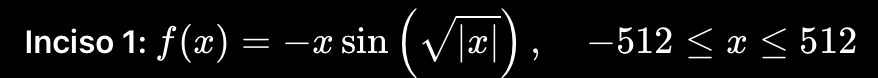

In [66]:
tamañoPoblacion = 20
aptitudRequerida = 418.98

poblacion = []
for i in range(tamañoPoblacion):
    poblacion.append(random.uniform(-512, 512))

algoritmo_evolutivo(poblacion, aptitudRequerida, reemplazo = 1, actividad = 1) 

Tamaño de la población: 20
Generacion: 1
mejorAptitud: 261.3702315923141
Generacion: 2
mejorAptitud: 363.936706001323
Generacion: 3
mejorAptitud: 382.6682431123425
Generacion: 4
mejorAptitud: 358.682195131188
Generacion: 5
mejorAptitud: 417.8725384273932
Generacion: 6
mejorAptitud: 417.8725384273932
Generacion: 7
mejorAptitud: 373.76485221096283
Generacion: 8
mejorAptitud: 418.49427060384335
Generacion: 9
mejorAptitud: 417.8725384273932
Generacion: 10
mejorAptitud: 417.8725384273932
Generacion: 11
mejorAptitud: 417.8725384273932
Generacion: 12
mejorAptitud: 418.8486470214627
Generacion: 13
mejorAptitud: 417.82263263500454
Generacion: 14
mejorAptitud: 418.8486470214627
Generacion: 15
mejorAptitud: 417.8725384273932
Generacion: 16
mejorAptitud: 374.7352916494154
Generacion: 17
mejorAptitud: 408.6971087411776
Generacion: 18
mejorAptitud: 394.73594476901184
Generacion: 19
mejorAptitud: 417.8725384273932
Generacion: 20
mejorAptitud: 417.8725384273932
Generacion: 21
mejorAptitud: 412.7431235

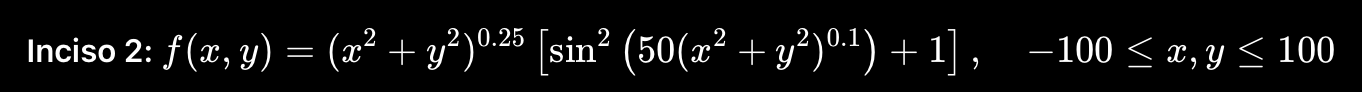

In [67]:
tamañoPoblacion = 20
aptitudRequerida = 0

poblacion = []
for i in range(tamañoPoblacion):
    x = random.uniform(-100, 100)
    y = random.uniform(-100, 100)
    poblacion.append((x, y))

algoritmo_evolutivo(poblacion, aptitudRequerida, reemplazo = 1, actividad = 2) 

Tamaño de la población: 20
Generacion: 1
mejorAptitud: -8.084110486354541
Generacion: 2
mejorAptitud: -4.489780170100593
Generacion: 3
mejorAptitud: -2.2728191537897904
Generacion: 4
mejorAptitud: -3.927816980850211
Generacion: 5
mejorAptitud: -3.927816980850211
Generacion: 6
mejorAptitud: -5.246952127384881
Generacion: 7
mejorAptitud: -4.373999554576136
Generacion: 8
mejorAptitud: -4.373999554576136
Generacion: 9
mejorAptitud: -5.154583681089205
Generacion: 10
mejorAptitud: -4.904325296469778
Generacion: 11
mejorAptitud: -3.8639994624865333
Generacion: 12
mejorAptitud: -3.8639994624865333
Generacion: 13
mejorAptitud: -4.218157369613895
Generacion: 14
mejorAptitud: -3.2090704998700446
Generacion: 15
mejorAptitud: -4.620285929551514
Generacion: 16
mejorAptitud: -4.6964107454396276
Generacion: 17
mejorAptitud: -6.216990765263543
Generacion: 18
mejorAptitud: -4.49159406096418
Generacion: 19
mejorAptitud: -3.5045017665933185
Generacion: 20
mejorAptitud: -3.5045017665933185
Generacion: 21
m

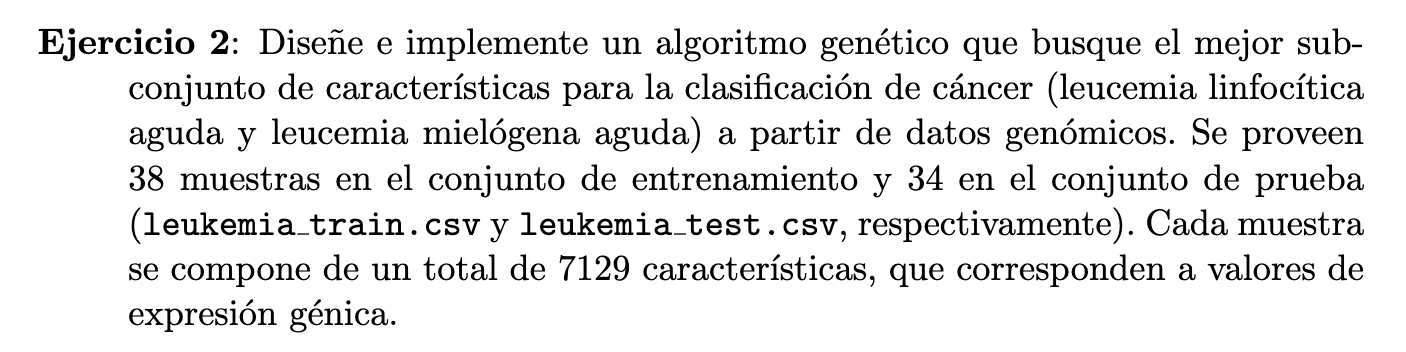

### Ejercicio 2

Este ejercicio me costó bastante entenderlo, pero yo lo interpreté de la siguiente manera:

Tengo varias muestras de pacientes. Cada paciente tiene información sobre **7129 genes**. Es decir, cada fila representa un paciente y cada columna representa un gen. El objetivo es encontrar qué subconjunto de esos genes permite distinguir mejor entre los dos tipos de leucemia.

Mi población está formada por **individuos que funcionan como máscaras binarias**. Cada posición de la máscara corresponde a un gen:

```text
Individuo |  1  |  1  |  0  |  0  |  1  |
```

Y los datos podrían verse así:

```text
          gen1  gen2  gen3  gen4  gen5
Paciente 1   x     x     x     x     x
Paciente 2   x     x     x     x     x
Paciente 3   x     x     x     x     x
```

Entonces aplico la máscara a todas las muestras. Los genes que tienen un `1` quedan seleccionados y los que tienen un `0` se descartan. En este ejemplo se seleccionarían los genes 1, 2 y 5.

Después utilizo solamente los genes seleccionados para entrenar un algoritmo que permita distinguir las dos clases de leucemia.

Yo utilicé **LVQ (Learning Vector Quantization)** porque es un algoritmo de clasificación supervisada y en el archivo `train` tengo las clases conocidas de cada paciente.

La idea de LVQ es tener un prototipo para cada clase. Cuando entra un patrón de entrenamiento, busco cuál de los prototipos está más cerca. Si el prototipo ganador pertenece a la misma clase que el patrón, lo acerco al patrón. Si pertenece a una clase diferente, lo alejo.

Se parece en cierta forma a K-medias porque también trabaja con prototipos y distancias, pero la diferencia importante es que LVQ utiliza las clases conocidas durante el entrenamiento.

Una vez entrenado LVQ utilizando los genes seleccionados por el individuo, utilizo el conjunto `test` para comprobar qué tan bien clasifica pacientes que no fueron utilizados para entrenar LVQ.

En este caso, la aptitud del individuo se basa en la cantidad de pacientes del conjunto de prueba que LVQ clasifica correctamente.

### Resumen

Cada individuo representa una **máscara que indica qué genes utilizar**. Aplico esa máscara a los datos, entreno LVQ utilizando solamente esos genes y después evalúo qué tan bien permite clasificar los pacientes.

Por lo tanto:

```text
Individuo
   ↓
Máscara de genes
   ↓
Genes seleccionados
   ↓
Entrenamiento de LVQ
   ↓
Clasificación de pacientes
   ↓
Aptitud
```

La idea del algoritmo evolutivo es ir generando diferentes máscaras y conservar las que producen mejores resultados de clasificación.



In [68]:
train = pd.read_csv("leukemia_train.csv")
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

test = pd.read_csv("leukemia_test.csv")
X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

#funcion que aplica la mascara a cada gen
def aplicar_mascara(individuo, X):
    columnas = []
    
    for i in range(len(individuo)):
        if individuo[i] == '1':
            columnas.append(i)

    return X.iloc[:, columnas]

#calculo la distancia entre el prototipo y el patron entrante, necesario para entrenar el LVQ
def distancia(a, b):
    suma = 0
    
    for i in range(len(a)):
        suma = suma + (a[i] - b[i]) ** 2

    return math.sqrt(suma)

#entrenamiento del clasificador
def entrenar_lvq(x, y, epocas = 20, tasa = 0.1):

    x = x.values
    y = y.values

    prototipos = []
    clases = [0, 1]

    for clase in clases:

        indices = []

        for i in range(len(y)):
            if y[i] == clase:
                indices.append(i)

        indice = random.choice(indices)

        prototipos.append(x[indice].copy())

    # Entrenamiento
    for epoca in range(epocas):

        for i in range(len(x)):

            patron = x[i]
            clase = y[i]

            distancias = []

            for j in range(len(prototipos)):

                d = distancia(patron, prototipos[j])
                distancias.append(d)

            indice_ganador = distancias.index(min(distancias))

            #si pertenece a la clase, lo acerco
            if clases[indice_ganador] == clase:
                for j in range(len(patron)):
                    prototipos[indice_ganador][j] = prototipos[indice_ganador][j] + tasa * (patron[j] - prototipos[indice_ganador][j])
            #si no pertenece, lo alejo
            else:
                for j in range(len(patron)):
                    prototipos[indice_ganador][j] = prototipos[indice_ganador][j] - tasa * (patron[j] - prototipos[indice_ganador][j])

        tasa = tasa * 0.95

    return prototipos, clases

#funcion para testear mi clasificador
def predecir_lvq(x, prototipos, clases):

    x = x.values

    predicciones = []

    for muestra in x:

        distancias = []

        for prototipo in prototipos:

            d = distancia(muestra, prototipo)
            distancias.append(d)

        indice_ganador = distancias.index(min(distancias))

        predicciones.append(clases[indice_ganador])

    return predicciones



In [69]:
tamañoPoblacion = 20
aptitudRequerida = 0.97

cantidadGenes = len(train.columns) - 1
poblacion = []
for i in range(tamañoPoblacion):
    individuo = []
    for j in range(cantidadGenes):
        individuo.append(str(random.randint(0, 1)))
    poblacion.append(individuo)

algoritmo_evolutivo(poblacion, aptitudRequerida, reemplazo = 1, actividad = 3)

Tamaño de la población: 20
Generacion: 1
mejorAptitud: 0.9696969696969697
Generacion: 2
mejorAptitud: 0.9696969696969697
Generacion: 3
mejorAptitud: 0.9696969696969697
Generacion: 4
mejorAptitud: 0.9696969696969697
Generacion: 5
mejorAptitud: 0.9696969696969697
Generacion: 6
mejorAptitud: 0.9696969696969697
Generacion: 7
mejorAptitud: 0.9696969696969697
Generacion: 8
mejorAptitud: 0.9696969696969697
Generacion: 9
mejorAptitud: 1.0
